# 05. Model Evaluation — ANN vs Logistic Regression vs Decision Tree vs Random Forest
### Final comparison table and model selection


In [1]:
import os
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
np.random.seed(42)

PROC_DIR = '../data/processed/crop_recom'
MODEL_DIR = '../models'
OUT_DIR = '../outputs/notebooks_task5'

os.makedirs(os.path.join(MODEL_DIR, 'ml_baselines'), exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

### Load the same benchmark split used for the ANN

In [2]:
data = np.load(os.path.join(PROC_DIR, 'benchmark_train_test_split.npz'))
X_train, X_test = data['X_train'], data['X_test']
y_train, y_test = data['y_train'], data['y_test']

label_encoder = joblib.load(os.path.join(MODEL_DIR, 'label_encoder_benchmark.pkl'))
class_names = label_encoder.classes_

print('X_train:', X_train.shape, ' X_test:', X_test.shape)
print('Classes:', list(class_names))

X_train: (1200, 7)  X_test: (300, 7)
Classes: ['Big Onion', 'Chillies (Green)', 'Cowpea', 'Gingelly', 'Green Gram', 'Ground Nuts', 'Kurakkan', 'Maize', 'Manioc', 'Meneri', 'Mustard', 'Potatoes', 'Red Onion', 'Sorghum', 'Sweet Potatoes']


### One evaluation function, used identically for every model

In [3]:
def train_and_evaluate(model, name, save_path=None):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro'
    )

    report = classification_report(y_test, y_pred, target_names=class_names, digits=3)
    cm = confusion_matrix(y_test, y_pred)

    if save_path:
        joblib.dump(model, save_path)

    return {
        'model': name,
        'test_accuracy': float(acc),
        'macro_precision': float(precision),
        'macro_recall': float(recall),
        'macro_f1': float(f1),
        'report': report,
        'confusion_matrix': cm,
        'fitted_model': model
    }

### Train the three baseline ML models

In [4]:
results = {}

results['Logistic Regression'] = train_and_evaluate(
    LogisticRegression(max_iter=1000, random_state=42),
    'Logistic Regression',
    os.path.join(MODEL_DIR, 'ml_baselines', 'logistic_regression.pkl')
)

results['Decision Tree'] = train_and_evaluate(
    DecisionTreeClassifier(random_state=42),
    'Decision Tree',
    os.path.join(MODEL_DIR, 'ml_baselines', 'decision_tree.pkl')
)

results['Random Forest'] = train_and_evaluate(
    RandomForestClassifier(n_estimators=200, random_state=42),
    'Random Forest',
    os.path.join(MODEL_DIR, 'ml_baselines', 'random_forest.pkl')
)

for name, r in results.items():
    print(f"{name:22s}  acc={r['test_accuracy']:.3f}  macro_f1={r['macro_f1']:.3f}")

Logistic Regression     acc=0.727  macro_f1=0.719
Decision Tree           acc=0.620  macro_f1=0.621
Random Forest           acc=0.753  macro_f1=0.751


### Bring in the ANN's results from 04_ann_training.ipynb

In [5]:
ann_results_path = '../outputs/notebooks_task4/04_ann_results.json'

if not os.path.exists(ann_results_path):
    raise FileNotFoundError(
        'Run 04_ann_training.ipynb first — it produces the ANN metrics this notebook compares against.'
    )

with open(ann_results_path) as f:
    ann_results = json.load(f)

print(ann_results)

{'model': 'ANN', 'test_accuracy': 0.7300000190734863, 'test_loss': 0.6803742051124573, 'macro_precision': 0.7399018480140691, 'macro_recall': 0.7300000000000001, 'macro_f1': 0.7128143850720955}


### Comparison table

In [6]:
comparison_rows = [ann_results]
for name, r in results.items():
    comparison_rows.append({
        'model': r['model'],
        'test_accuracy': r['test_accuracy'],
        'macro_precision': r['macro_precision'],
        'macro_recall': r['macro_recall'],
        'macro_f1': r['macro_f1']
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('test_accuracy', ascending=False)
comparison_df = comparison_df.set_index('model')
comparison_df

,test_accuracy,test_loss,macro_precision,macro_recall,macro_f1
model,,,,,
Random Forest,0.753333,NaN,0.753188,0.753333,0.751296
ANN,0.730000,0.680374,0.739902,0.730000,0.712814
Logistic Regression,0.726667,NaN,0.723740,0.726667,0.718887
Decision Tree,0.620000,NaN,0.631747,0.620000,0.620962


In [7]:
comparison_df.to_csv(os.path.join(OUT_DIR, '05_model_comparison.csv'))
print('Saved ->', os.path.join(OUT_DIR, '05_model_comparison.csv'))

Saved -> ../outputs/notebooks_task5\05_model_comparison.csv


### Visual comparison

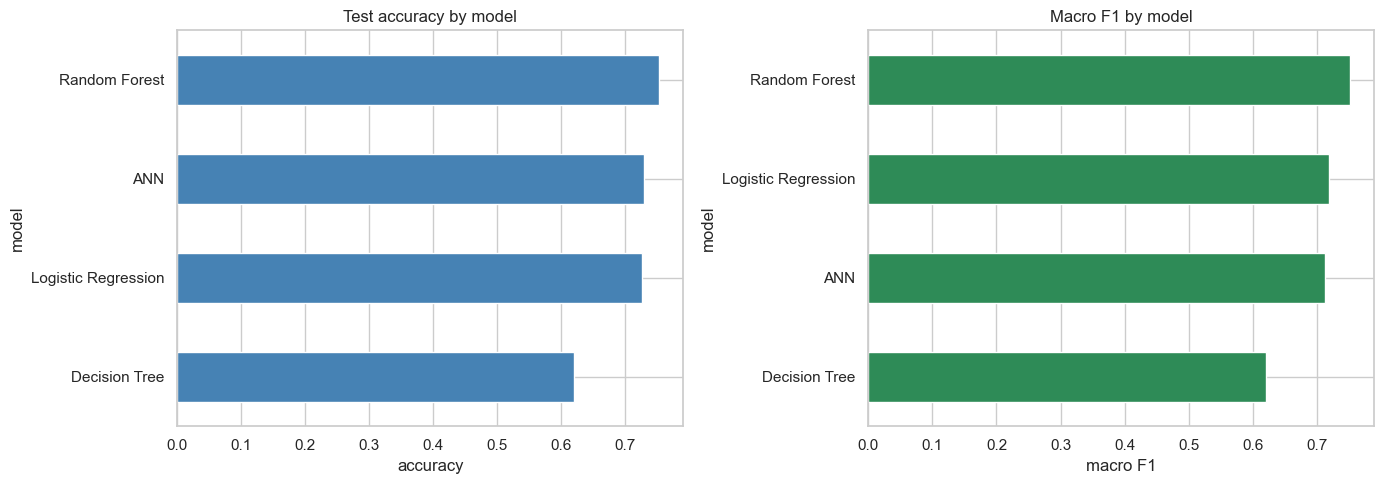

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison_df['test_accuracy'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_title('Test accuracy by model')
axes[0].set_xlabel('accuracy')

comparison_df['macro_f1'].sort_values().plot(
    kind='barh', ax=axes[1], color='seagreen'
)
axes[1].set_title('Macro F1 by model')
axes[1].set_xlabel('macro F1')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '01_model_comparison_bars.png'), dpi=120)
plt.show()

### Confusion matrices — the three ML baselines

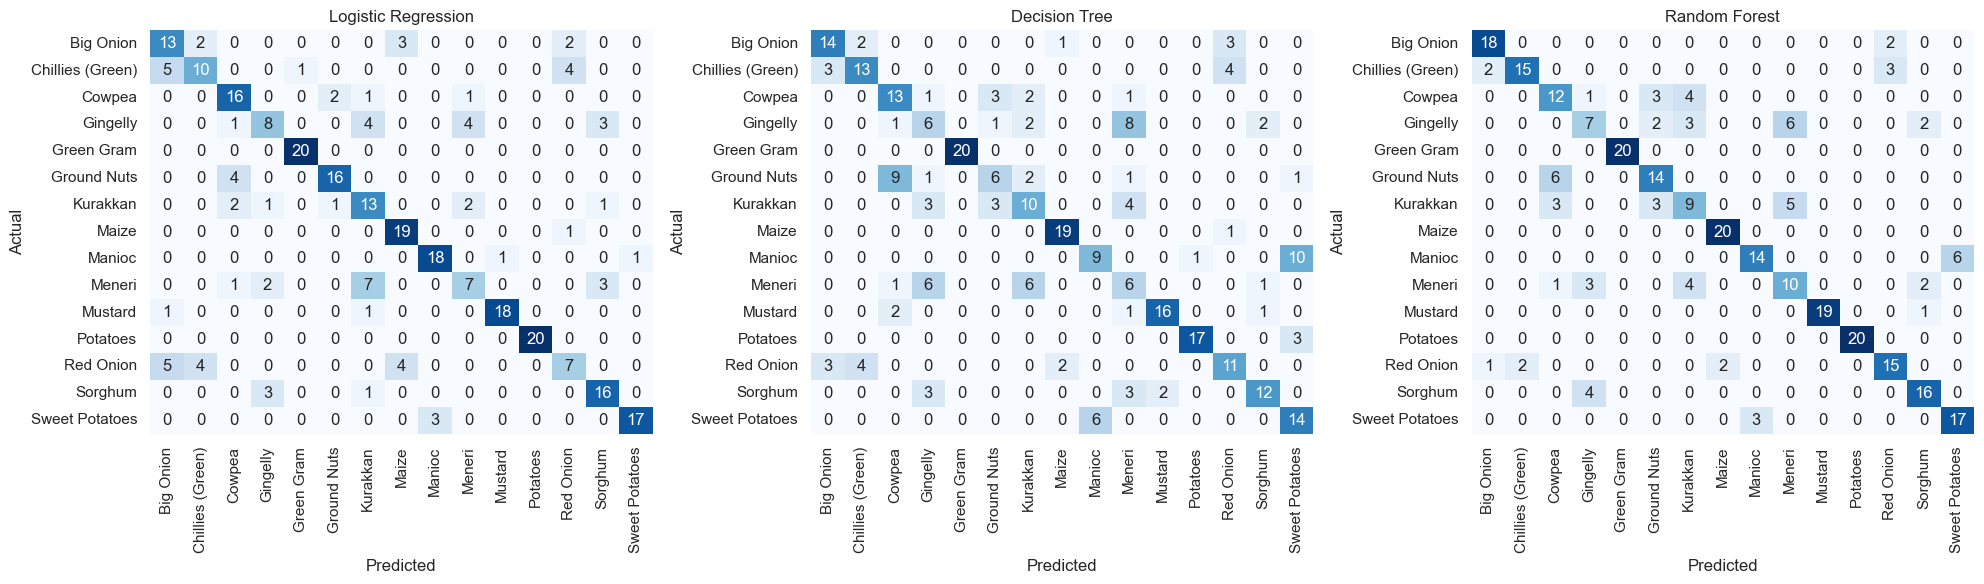

(ANN confusion matrix is in outputs/notebooks_task4/04_ann_confusion_matrix.png)


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, r) in zip(axes, results.items()):
    sns.heatmap(r['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=90)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '02_ml_confusion_matrices.png'), dpi=120)
plt.show()

print('(ANN confusion matrix is in outputs/notebooks_task4/04_ann_confusion_matrix.png)')

### Per-class reports for the two strongest baselines

In [11]:
for name in ['Random Forest', 'Logistic Regression']:
    print(f'=== {name} ===')
    print(results[name]['report'])
    print()

=== Random Forest ===
                  precision    recall  f1-score   support

       Big Onion      0.857     0.900     0.878        20
Chillies (Green)      0.882     0.750     0.811        20
          Cowpea      0.545     0.600     0.571        20
        Gingelly      0.467     0.350     0.400        20
      Green Gram      1.000     1.000     1.000        20
     Ground Nuts      0.636     0.700     0.667        20
        Kurakkan      0.450     0.450     0.450        20
           Maize      0.909     1.000     0.952        20
          Manioc      0.824     0.700     0.757        20
          Meneri      0.476     0.500     0.488        20
         Mustard      1.000     0.950     0.974        20
        Potatoes      1.000     1.000     1.000        20
       Red Onion      0.750     0.750     0.750        20
         Sorghum      0.762     0.800     0.780        20
  Sweet Potatoes      0.739     0.850     0.791        20

        accuracy                          0.753 

### Select the Best Model

In [15]:
best_row = comparison_df.reset_index().sort_values(
    ['test_accuracy', 'macro_f1'], ascending=False
).iloc[0]

best_model_name = best_row['model']
print('Best model:', best_model_name)
print(best_row)

if best_model_name == 'ANN':
    best_model_info = {
        'model_name': 'ANN',
        'model_type': 'keras',
        'model_path': 'models/ann_crop_recommender.keras'
    }
else:
    filename_map = {
        'Logistic Regression': 'logistic_regression.pkl',
        'Decision Tree': 'decision_tree.pkl',
        'Random Forest': 'random_forest.pkl'
    }
    best_model_info = {
        'model_name': best_model_name,
        'model_type': 'sklearn',
        'model_path': f'models/ml_baselines/{filename_map[best_model_name]}'
    }

with open(os.path.join(MODEL_DIR, 'best_model_info.json'), 'w') as f:
    json.dump(best_model_info, f, indent=2)

print('Saved ->', os.path.join(MODEL_DIR, 'best_model_info.json'))
print(best_model_info)

Best model: Random Forest
model              Random Forest
test_accuracy           0.753333
test_loss                    NaN
macro_precision         0.753188
macro_recall            0.753333
macro_f1                0.751296
Name: 0, dtype: object
Saved -> ../models\best_model_info.json
{'model_name': 'Random Forest', 'model_type': 'sklearn', 'model_path': 'models/ml_baselines/random_forest.pkl'}
